In [34]:
import pandas as pd

In [35]:
df= pd.read_csv("../data/my2015-2024-fuel-consumption-ratings.csv")
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


In [36]:
df.isna().sum()

Model year                 0
Make                       0
Model                      0
Vehicle class              0
Engine size (L)            0
Cylinders                  0
Transmission               0
Fuel type                  0
City (L/100 km)            0
Highway (L/100 km)         0
Combined (L/100 km)        0
Combined (mpg)             0
CO2 emissions (g/km)       0
CO2 rating              1128
Smog rating             2234
dtype: int64

In [37]:
df.loc[
    df["Smog rating"].isna(),"Model year"
].value_counts().sort_index()

Model year
2015    1128
2016    1106
Name: count, dtype: int64

In [38]:
df= df.loc[
    df["Model year"] >= 2017
].copy()
df.shape

(7826, 15)

In [39]:
df.isna().sum()

Model year              0
Make                    0
Model                   0
Vehicle class           0
Engine size (L)         0
Cylinders               0
Transmission            0
Fuel type               0
City (L/100 km)         0
Highway (L/100 km)      0
Combined (L/100 km)     0
Combined (mpg)          0
CO2 emissions (g/km)    0
CO2 rating              0
Smog rating             0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

**Le nettoyage des donnees est fait, la prochaine etape est la preparation des donnees**

In [41]:
df["Smog rating"].value_counts().sort_index()

Smog rating
1.0     563
2.0       7
3.0    1915
5.0    2431
6.0    1278
7.0    1507
8.0     125
Name: count, dtype: int64

**smog rating 2.0 = 7**

tres peu de voiture avec le smog rating de 2.0 se qui risque d'affecter l'entrainement du model

pour le model de classification sa serait plus interessant de diviser le smog rating en 3 categorie:


 Note de smog  |  Catégorie     | Nombre de véhicules
-------------- | -------------- | --------------------
   1–3         |    Note faible |               2 485
   4–6         |   Note moyenne |              3 709
   7–10        |    Note élevée |              1 632

In [42]:
df["Classe smog"] = pd.cut(
    df["Smog rating"],
    bins=[0, 3, 6, 10],
    labels=["Note faible", "Note moyenne", "Note elevee"],
)

df["Classe smog"].value_counts().sort_index()

Classe smog
Note faible     2485
Note moyenne    3709
Note elevee     1632
Name: count, dtype: int64

<Axes: title={'center': 'Nombre de vehicules par categorie de smog'}, xlabel='Categorie', ylabel='Nombre de vehicules'>

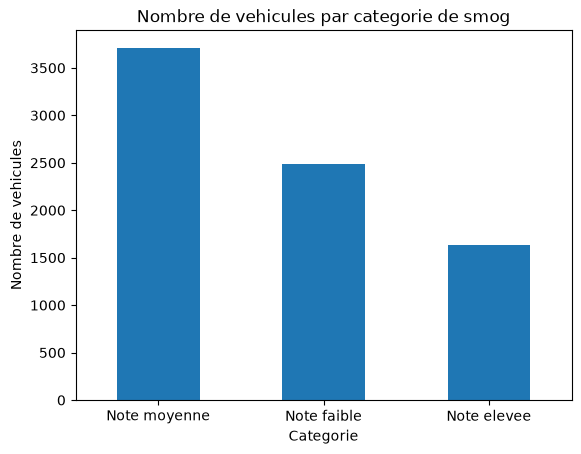

In [43]:
df["Classe smog"].value_counts().plot.bar(
    title= "Nombre de vehicules par categorie de smog",
    xlabel= "Categorie",
    ylabel= "Nombre de vehicules",
    rot=0
)

In [44]:
df["Combined (L/100 km)"].describe()

count    7826.000000
mean       11.002977
std         2.798086
min         4.000000
25%         9.100000
50%        10.700000
75%        12.700000
max        26.100000
Name: Combined (L/100 km), dtype: float64

le max a 26 a l'air tres elever comparer au autre, on va investiger d'ou viens se chiffre

In [45]:
df.nlargest(5,"Combined (L/100 km)")[["Make", "Model year", "Model", "Combined (L/100 km)"]]

,Make,Model year,Model,Combined (L/100 km)
6532,Bugatti,2021,Chiron Pur Sport,26.1
7510,Bugatti,2022,Chiron Pur Sport,26.1
7511,Bugatti,2022,Chiron Super Sport,26.1
8482,Bugatti,2023,Chiron Pur Sport,26.1
8483,Bugatti,2023,Chiron Super Sport,26.1


<Axes: title={'center': 'Repartition de la consommation'}, xlabel='Consomation combinee (L/100 km)', ylabel='Nombre de vehicules'>

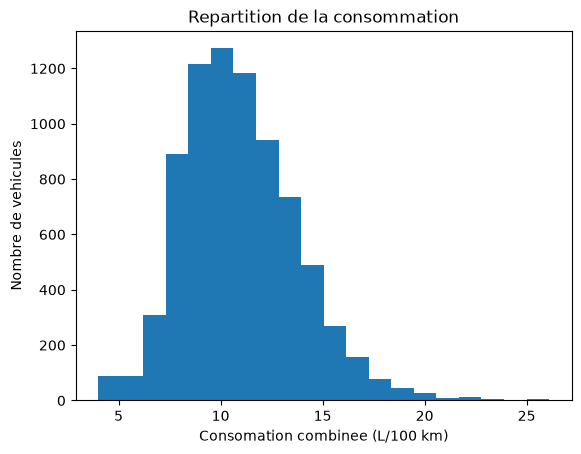

In [46]:
df["Combined (L/100 km)"].plot.hist(
    bins=20,
    title= "Repartition de la consommation",
    xlabel= "Consomation combinee (L/100 km)",
    ylabel= "Nombre de vehicules"
)

In [47]:
features = [
    "Model year",
    "Make",
    "Vehicle class",
    "Engine size (L)",
    "Cylinders",
    "Transmission",
    "Fuel type"
]

df[features].head()

,Model year,Make,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type
2234,2017,Acura,Compact,2.4,4,AM8,Z
2235,2017,Acura,Sport utility vehicle: Small,3.0,6,AM7,Z
2236,2017,Acura,Sport utility vehicle: Small,3.5,6,AS9,Z
2237,2017,Acura,Sport utility vehicle: Small,3.5,6,AS9,Z
2238,2017,Acura,Two-seater,3.5,6,AM9,Z


In [48]:
target_regression = "Combined (L/100 km)"
target_classification = "Classe smog"

df[[target_regression, target_classification]].head()

,Combined (L/100 km),Classe smog
2234,8.2,Note moyenne
2235,9.0,Note moyenne
2236,11.0,Note moyenne
2237,10.7,Note moyenne
2238,11.0,Note moyenne


In [49]:
df["Model year"].value_counts().sort_index()

Model year
2017    1058
2018    1083
2019    1056
2020     975
2021     970
2022     976
2023     919
2024     789
Name: count, dtype: int64

Maintenant nous allons diviser les donnees en 3 partie: entrainement, validation  et test final.

   donnees      | Annee      | Raison
   -------------|------------|----------------------------------
   Entrainement | 2017–2022  | entrainer les models
   Validation   | 2023       | Comparer les models et choisir les parametres
   Test final   | 2024       | Evaluer le model champion
  

In [55]:
train_df = df.loc[
    df["Model year"] < 2023].copy()
validation_df = df.loc[
    df["Model year"] == 2023].copy()
test_df = df.loc[
    df["Model year"] == 2024].copy()

print("Entrainement: ", len(train_df))
print("Validation: ", len(validation_df))
print("Test final: ", len(test_df))

Entrainement:  6118
Validation:  919
Test final:  789


**Une fois Preprocessing.py de cree il est temps d'utiliser le script pyton**

In [ ]:
%run ../src/preprocessing.py

prepared_df = prepare_data(
    "../data/my2015-2024-fuel-consumption-ratings.csv"
)

print("Dimensions du fichier préparé: ", prepared_df.shape)

train_df, validation_df, test_df = split_data(prepared_df)

print("Entrainement: ", len(train_df))
print("Validation: ", len(validation_df))
print("Test final: ", len(test_df))

Entrainement:  6118
Validation:  919
Test final:  789
